# 1 — Imports & root detection

In [1]:
# %% [markdown]
# # ConvNeXt Optimised V6 (224px)
# Architecture: ConvNeXT_OptimisedV2
# Training: EMA + AMP + MixUp/CutMix + tuned Erasing + Label Smoothing

# %% 1 — Imports & Root Detection
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torchvision.transforms import RandomErasing
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score
)

# Notebook‑safe project root detection
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ConvNeXT_Optimised import ConvNeXT_OptimisedV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Project root: c:\repo\Waste-Classification
Device: cuda


# 2 — Hyperparameters

In [2]:
# %% 2 — Hyperparameters (V6)
EPOCHS        = 100
BATCH_SIZE    = 32
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT       = 0.4
HEAD_DEPTH    = 2
NUM_CLASSES   = 28
EMA_DECAY     = 0.999
ERASE_P       = 0.05
LABEL_SMOOTH  = 0.03

CUTMIX_ALPHA  = 0.4
CUTMIX_P      = 0.5   # probability of using CutMix instead of MixUp for a batch

print("Epochs       :", EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("LR           :", LR)
print("Dropout      :", DROPOUT)
print("Head depth   :", HEAD_DEPTH)
print("EMA decay    :", EMA_DECAY)
print("Erase p      :", ERASE_P)
print("Label smooth :", LABEL_SMOOTH)
print("CutMix alpha :", CUTMIX_ALPHA)
print("CutMix p     :", CUTMIX_P)


Epochs       : 100
Batch size   : 32
LR           : 0.0001
Dropout      : 0.4
Head depth   : 2
EMA decay    : 0.999
Erase p      : 0.05
Label smooth : 0.03
CutMix alpha : 0.4
CutMix p     : 0.5


# 3 — Data pipeline

In [3]:
# %% 3 — Data Pipeline (ConvNeXt augmentations)
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/Warp-C",
    processed_root = root / "Dataset/processed",
    stats_file     = root / "Dataset/dataset_stats.json",
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type="convnext")

CLASS_NAMES = sorted(
    d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir()
)

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")


[get_loaders] model='convnext'
  sampler=True  minority_aug=True  mixup=True  pipeline='transformer'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


# 4 — EMA helper

In [4]:
# %% 4 — EMA Helper
import copy

class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, p in zip(self.ema.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    @torch.no_grad()
    def evaluate(self, loader):
        self.ema.eval()
        correct = total = 0
        for imgs, lbls in loader:
            preds = self.ema(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
        return correct / total * 100


# 5 — CutMix helper

In [5]:
# %% 5 — CutMix Helper
def rand_bbox(W, H, lam):
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2


def apply_cutmix(images, labels, num_classes, alpha=1.0):
    """Return (mixed_images, soft_labels) using CutMix."""
    batch_size, _, H, W = images.size()
    indices = torch.randperm(batch_size, device=images.device)

    lam = np.random.beta(alpha, alpha)
    x1, y1, x2, y2 = rand_bbox(W, H, lam)

    images_mixed = images.clone()
    images_mixed[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]

    lam_adjusted = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))

    labels_onehot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()
    labels_shuffled = labels_onehot[indices]
    soft_labels = lam_adjusted * labels_onehot + (1.0 - lam_adjusted) * labels_shuffled

    return images_mixed, soft_labels


# 6 — Loss, model, optimiser, scheduler, AMP, erasing

In [6]:
# %% 6 — Loss, Model, Optimizer, Scheduler, AMP, Erasing
class_weights = pp.get_class_weights(device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

model = ConvNeXT_OptimisedV2(
    num_classes     = NUM_CLASSES,
    dropout         = DROPOUT,
    head_depth      = HEAD_DEPTH,
    freeze_backbone = False,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = EPOCHS,
    eta_min = 1e-7,
)

ema    = ModelEMA(model, decay=EMA_DECAY)
scaler = GradScaler(enabled=(DEVICE == "cuda"))

eraser = RandomErasing(
    p=ERASE_P,
    scale=(0.02, 0.15),
    ratio=(0.3, 3.3),
    value="random",
)

with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)
    y = model(x)
print("Sanity output:", y.shape)


Loss: CrossEntropyLoss + class weights


C:\Users\scott\AppData\Local\Temp\ipykernel_11780\1116172118.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE == "cuda"))


Sanity output: torch.Size([2, 28])


# 7 — Training loop (MixUp/CutMix + LS + EMA + AMP + Erasing)

In [7]:
# %% 7 — Training Loop (MixUp/CutMix + LS + EMA + AMP + Erasing)
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

WEIGHTS_PATH = root / "Models/weights/convnext_optimised_v6_224.pth"

print(f"Starting {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    ep_loss = correct = total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        use_cutmix = np.random.rand() < CUTMIX_P

        if use_cutmix:
            # CutMix
            imgs_aug, soft_lbls = apply_cutmix(
                images     = imgs,
                labels     = lbls,
                num_classes= NUM_CLASSES,
                alpha      = CUTMIX_ALPHA,
            )
        else:
            # MixUp (same as previous versions)
            imgs_aug, soft_lbls = WaRPPreprocessor.mixup_batch(
                images      = imgs,
                labels      = lbls,
                num_classes = NUM_CLASSES,
                alpha       = 0.4,
            )

        # Label smoothing on soft labels
        if LABEL_SMOOTH > 0.0:
            soft_lbls = (1.0 - LABEL_SMOOTH) * soft_lbls + LABEL_SMOOTH / NUM_CLASSES

        # Random Erasing after MixUp/CutMix
        imgs_aug = eraser(imgs_aug)

        optimizer.zero_grad()

        with autocast(enabled=(DEVICE == "cuda")):
            logits = model(imgs_aug)
            log_p  = torch.nn.functional.log_softmax(logits, dim=1)
            loss   = -(soft_lbls * log_p).sum(dim=1).mean()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # EMA update
        ema.update(model)

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    scheduler.step()

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluate EMA model
    test_acc = ema.evaluate(test_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(ema.ema.state_dict(), WEIGHTS_PATH)
        flag = " ← best"
    else:
        flag = ""

    print(
        f"Epoch {epoch:3d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
        f"test(EMA)={test_acc:.2f}% | best={best_acc:.2f}% | "
        f"{time.time()-t0:.1f}s{flag}"
    )


Starting 100 epochs...



C:\Users\scott\AppData\Local\Temp\ipykernel_11780\889810161.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == "cuda")):


Epoch   1/100 | loss=2.7515 | train=19.32% | test(EMA)=12.51% | best=12.51% | 45.0s ← best
Epoch   2/100 | loss=1.9838 | train=36.60% | test(EMA)=36.23% | best=36.23% | 29.6s ← best
Epoch   3/100 | loss=1.8006 | train=40.71% | test(EMA)=53.00% | best=53.00% | 29.6s ← best
Epoch   4/100 | loss=1.7107 | train=47.10% | test(EMA)=63.83% | best=63.83% | 29.6s ← best
Epoch   5/100 | loss=1.6299 | train=47.96% | test(EMA)=69.83% | best=69.83% | 29.5s ← best
Epoch   6/100 | loss=1.5605 | train=48.12% | test(EMA)=73.31% | best=73.31% | 29.6s ← best
Epoch   7/100 | loss=1.4720 | train=52.96% | test(EMA)=75.50% | best=75.50% | 29.6s ← best
Epoch   8/100 | loss=1.4406 | train=52.93% | test(EMA)=76.72% | best=76.72% | 29.6s ← best
Epoch   9/100 | loss=1.4769 | train=51.87% | test(EMA)=78.79% | best=78.79% | 29.6s ← best
Epoch  10/100 | loss=1.3745 | train=53.73% | test(EMA)=79.95% | best=79.95% | 30.0s ← best
Epoch  11/100 | loss=1.3891 | train=51.84% | test(EMA)=80.92% | best=80.92% | 29.6s ← best

# 8 — Training curves

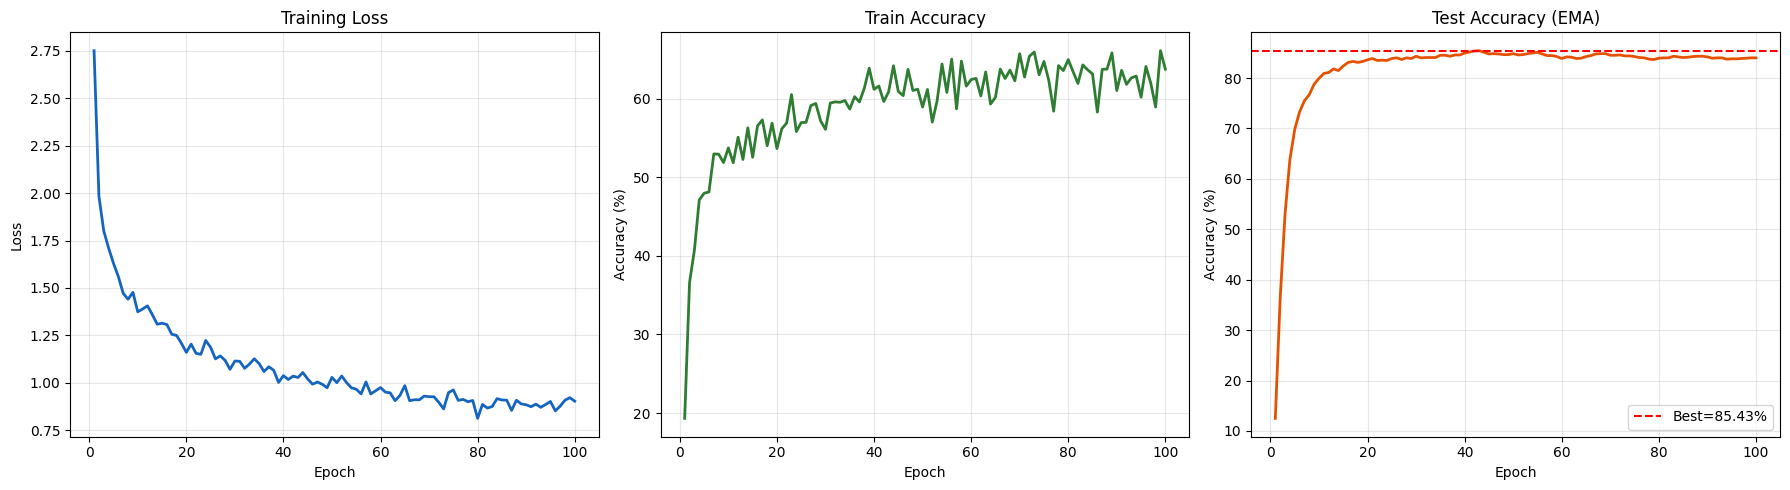

In [8]:
# %% 8 — Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(max(test_accs), color="red", ls="--",
                label=f"Best={max(test_accs):.2f}%")
axes[2].set(title="Test Accuracy (EMA)", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 9 — Final evaluation + confusion matrix

ConvNeXt Optimised V6 (224px, EMA+AMP+MixUp/CutMix+Erasing+LS) — Final Metrics
Accuracy     : 85.43%
Macro F1     : 83.30%
Weighted F1  : 85.38%
Precision    : 84.28%
Recall       : 83.30%


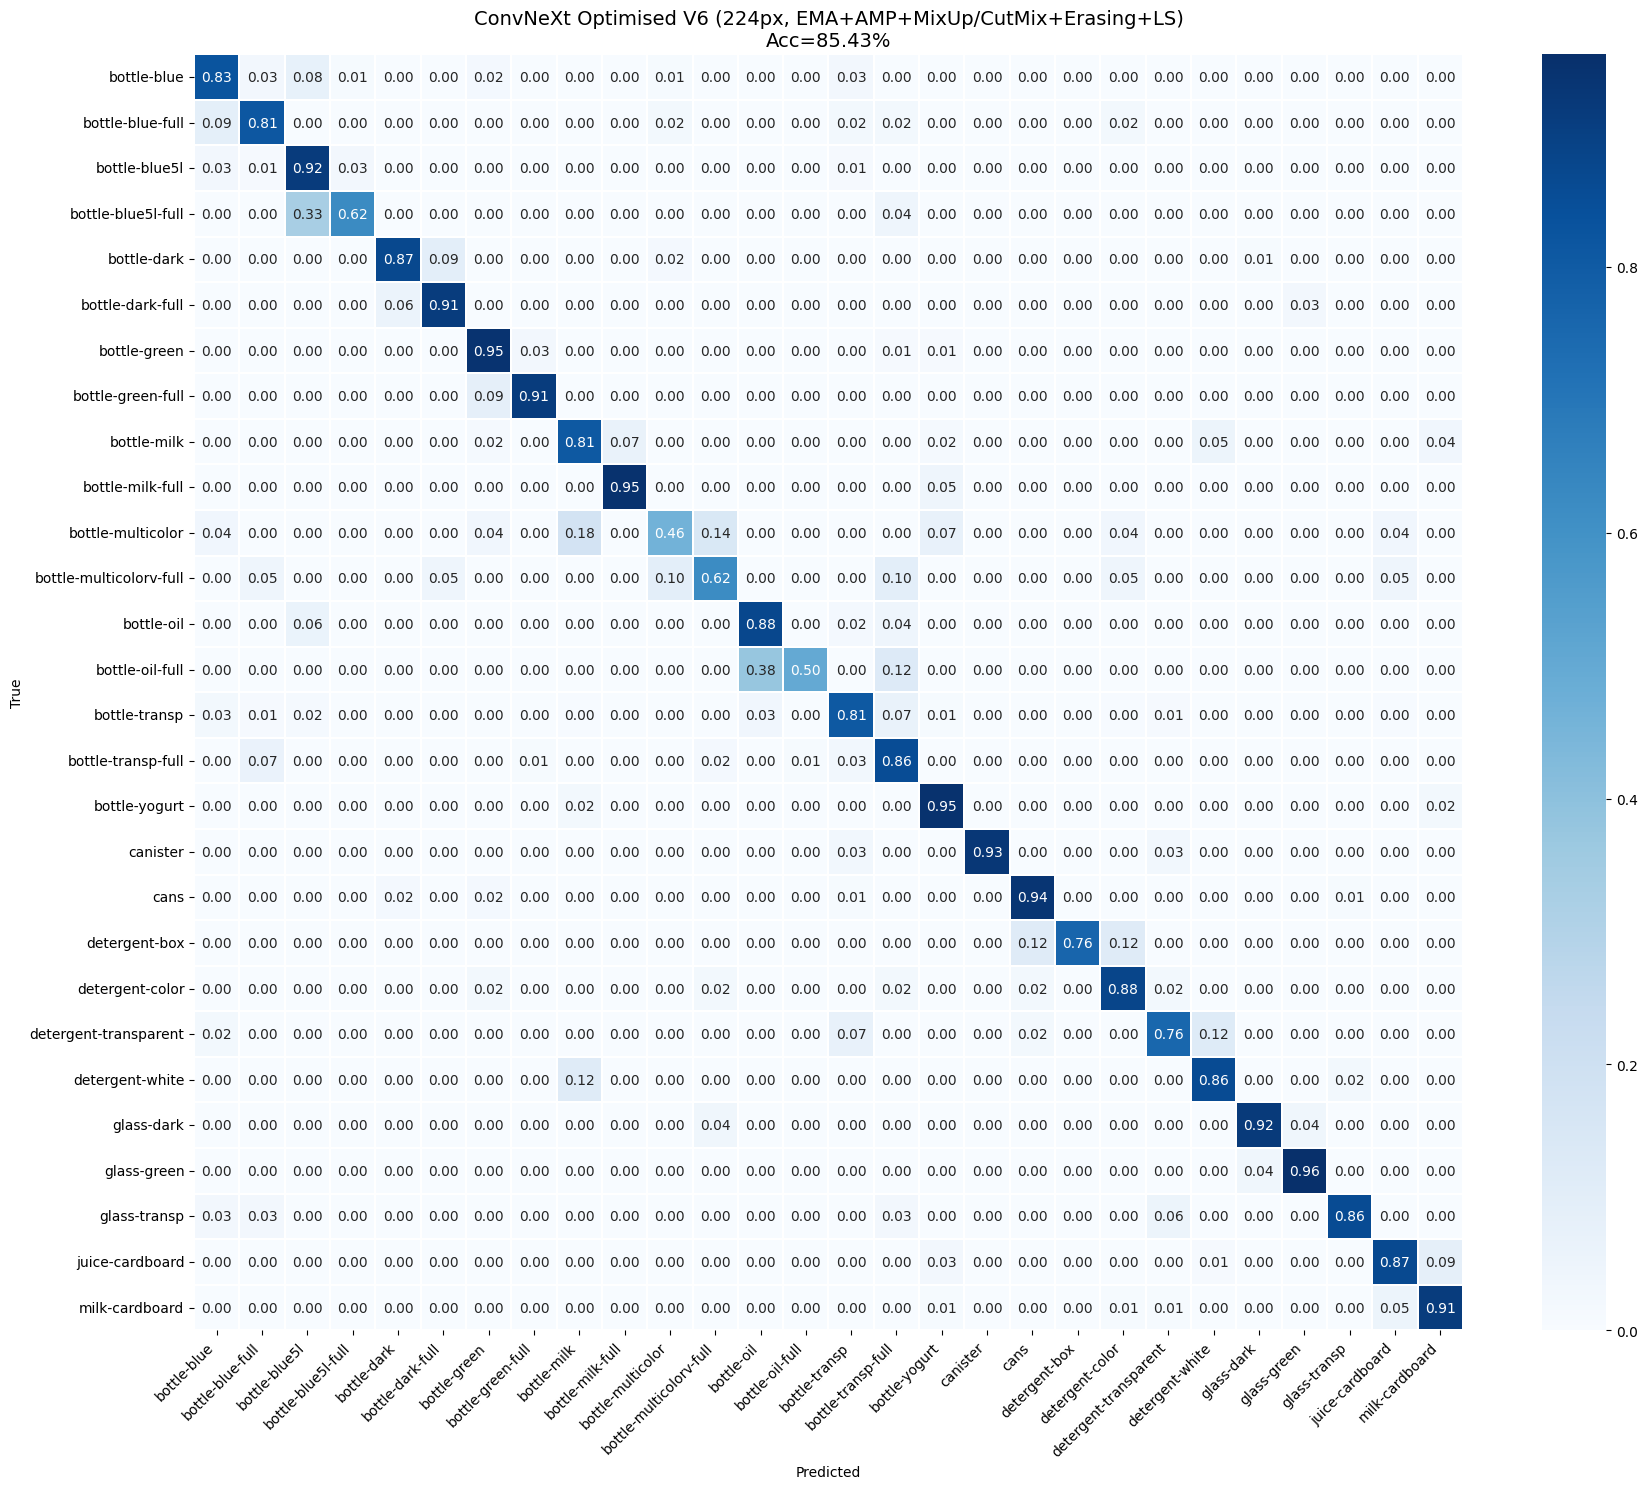

In [9]:
# %% 9 — Final Evaluation + Confusion Matrix
model = ConvNeXT_OptimisedV2(
    num_classes     = NUM_CLASSES,
    dropout         = DROPOUT,
    head_depth      = HEAD_DEPTH,
    freeze_backbone = False,
).to(DEVICE)

state = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

acc         = (y_pred == y_true).mean() * 100
macro_f1    = f1_score(y_true, y_pred, average="macro") * 100
weighted_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec        = precision_score(y_true, y_pred, average="macro") * 100
rec         = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("ConvNeXt Optimised V6 (224px, EMA+AMP+MixUp/CutMix+Erasing+LS) — Final Metrics")
print("="*50)
print(f"Accuracy     : {acc:.2f}%")
print(f"Macro F1     : {macro_f1:.2f}%")
print(f"Weighted F1  : {weighted_f1:.2f}%")
print(f"Precision    : {prec:.2f}%")
print(f"Recall       : {rec:.2f}%")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3,
)
ax.set_title(
    f"ConvNeXt Optimised V6 (224px, EMA+AMP+MixUp/CutMix+Erasing+LS)\nAcc={acc:.2f}%",
    fontsize=14,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
